# Constellation Detection
**CS-GY 6643 — Fall 2026**  
**Team / NetIDs:** add before course submission.

Locate each query's center, reject absent queries, and identify the constellation from its reference geometry. Run all cells from the project directory with `Data/`, `constellation.py`, and the dependencies in `requirements.txt`. Image matching is cached; a cold run is substantially slower.

Verified from the supplied screenshot: v2 scored **0.90637** and v3 scored **0.90392** publicly. This notebook generates v4; its public/private scores require separate verification.

## 1. Load inputs
Read the supplied training labels and submission template. Preserve identifiers, query counts, and input files.

In [1]:
from pathlib import Path
import ast, csv, hashlib, json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import constellation as cd

DATA = Path("Data")
OUT = Path("outputs/q5")
CACHE = OUT / "cache"
OUT.mkdir(parents=True, exist_ok=True)
cd.cv2.setNumThreads(1)
cd.cv2.setRNGSeed(7)

def read_rows(path):
    with path.open(newline="") as handle:
        return list(csv.DictReader(handle))

training_rows = read_rows(DATA / "train_ground_truth.csv")
sample_rows = read_rows(DATA / "sample_submission.csv")
input_hashes = {str(p): hashlib.sha256(p.read_bytes()).hexdigest()
                for p in sorted(DATA.rglob("*")) if p.is_file() and p.suffix in (".png", ".csv")}
print(f"{len(training_rows)} labeled scenes; {len(sample_rows)} competition scenes")
print(f"NumPy {np.__version__}; OpenCV {cd.cv2.__version__}")

3 labeled scenes; 16 competition scenes
NumPy 2.5.3; OpenCV 5.0.0


## 2. Extract reference stars
Detect white marker components, reject tiny outline fragments, and merge nearby peaks within a single marker. Separate peaks are retained for genuinely touching stars.

In [2]:
patterns = cd.read_patterns(DATA / "patterns")
print(f"{len(patterns)} reference drawings; node counts: {min(map(len, patterns.values()))}–{max(map(len, patterns.values()))}")

48 reference drawings; node counts: 2–28


## 3. Match query images
Subtract smooth backgrounds, then search rotation and scale using normalized correlation and SIFT proposals. Refine candidate transforms with affine correlation and compare aligned intensities, residuals, and fine texture. Retain distinct alternatives instead of accepting every best match. Recheck fitted intensities after clipping to the image range, and measure smooth residual structure: a wrong alignment can leave coherent errors even when random noise dominates individual pixels. These two extra measurements reuse cached transforms.

In [3]:
training_evidence = {
    row["Id"]: cd.analyze_scene(DATA / "train" / row["Id"], CACHE)
    for row in training_rows
}
# Diagnostic only: is a correct location among the retained alternatives?
for row in training_rows:
    total = retained = first = 0
    for i, matches in enumerate(training_evidence[row["Id"]], 1):
        truth = ast.literal_eval(row[f"patch_{i:02}"])
        if truth == -1:
            continue
        total += 1
        distances = [np.hypot(m["x"]-truth[0], m["y"]-truth[1]) for m in matches]
        retained += any(d <= 12 for d in distances)
        first += bool(distances and distances[0] <= 12)
    print(f"{row['Id']}: first candidate {first}/{total}; retained candidate recall {retained}/{total}")

pisces: first candidate 25/27; retained candidate recall 27/27
scorpius: first candidate 22/26; retained candidate recall 26/26
taurus: first candidate 15/18; retained candidate recall 17/18


## 4. Calibrate matches and recover geometry
A regularized logistic model scores image-match evidence. Reference matching uses star contrast at several scales, partial geometric consensus, fit residuals, and sky verification. Broader alternatives help identify a constellation; only image candidates within 10% of the best match probability can change an already selected location. This limits geometric overrides of better image evidence. Present off-figure queries remain valid detections.

For each diagnostic fold, fit calibration on two scenes and evaluate the third. All three scenes influenced method development, so these results are **not an untouched generalization estimate**. The local scorer follows the handout; the official treatment of membership flags and edge cases remains unverified.

For a rejected query, fit the selected constellation using other queries only. Prefer an affine transform; allow a projective transform when at least six inliers support it. Predict each supporting point with that point withheld and require every error to be at most 12 pixels. Restore a query only if an existing image candidate lies within 6 pixels of a predicted reference star, has match probability at least 0.01, and retains at least half the best candidate probability. Resolve competing recoveries one-to-one. Accepted positions remain unchanged. These constants were checked on the development scenes, not an untouched test set.


Version 5 preserves an affine recovery fit when all withheld-point errors are at most six pixels. Otherwise it also checks a projective fit, accepting the extra flexibility only if the maximum withheld-point error improves by at least 25%. The existing six-pixel candidate-distance and image-confidence guards remain. This compares predictive geometry without changing image search or calibration.


In [4]:
cross_validation = {}
for row in training_rows:
    other_rows = [r for r in training_rows if r["Id"] != row["Id"]]
    calibration = cd.fit_calibration(*cd.calibration_data(other_rows, training_evidence))
    sky = cd.cv2.imread(str(DATA / "train" / row["Id"] / f"{row['Id']}_image.png"), 0)
    prediction = cd.predict_scene(training_evidence[row["Id"]], calibration, patterns, sky)
    cross_validation[row["Id"]] = {
        "prediction": prediction, "metrics": cd.score_scene(row, prediction)
    }
columns = ["Presence", "Localization", "GeometricRecovery", "Identification", "Score"]
table = "| Held-out scene | Predicted name | " + " | ".join(columns) + " |\n"
table += "|---|---|" + "---:|" * len(columns) + "\n"
for name, result in cross_validation.items():
    table += f"| {name} | {result['prediction']['constellation']} | "
    table += " | ".join(f"{result['metrics'][c]:.4f}" for c in columns) + " |\n"
display(Markdown(table))
mean_score = np.mean([r["metrics"]["Score"] for r in cross_validation.values()])
print(f"Mean development score: {mean_score:.4f}; revised Kaggle public/private scores: unmeasured")
(OUT / "cross_validation_v5.json").write_text(json.dumps(cross_validation, indent=2))

| Held-out scene | Predicted name | Presence | Localization | GeometricRecovery | Identification | Score |
|---|---|---:|---:|---:|---:|---:|
| pisces | pisces | 0.9458 | 0.9630 | 1.0000 | 1.0000 | 0.9790 |
| scorpius | scorpius | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| taurus | taurus | 0.9706 | 0.9444 | 1.0000 | 1.0000 | 0.9815 |


Mean development score: 0.9869; revised Kaggle public/private scores: unmeasured


158440

## 5. Inspect recovered positions
Cyan marks predicted figure stars; orange marks present off-figure queries. These are predictions on the labeled development scenes.

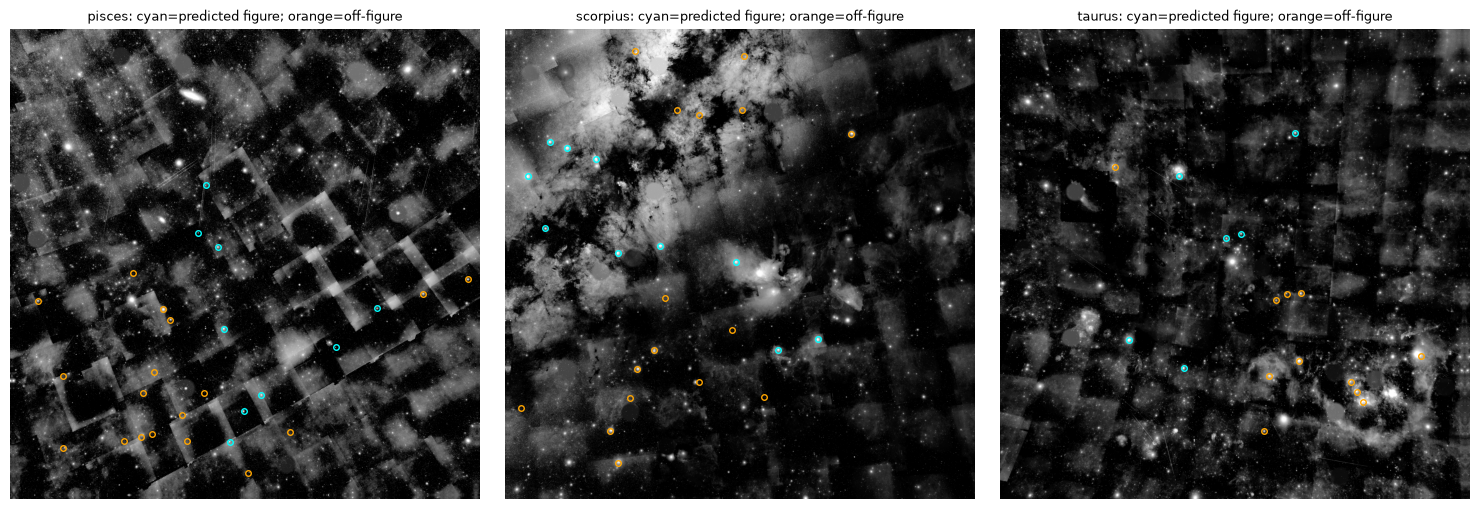

In [5]:
fig, axes = plt.subplots(1, len(training_rows), figsize=(15, 5))
for ax, row in zip(np.atleast_1d(axes), training_rows):
    sky = cd.cv2.imread(str(DATA / "train" / row["Id"] / f"{row['Id']}_image.png"), 0)
    ax.imshow(sky, cmap="gray")
    for value in cross_validation[row["Id"]]["prediction"]["patches"]:
        if value != -1:
            ax.plot(value[0], value[1], "o", ms=4, mfc="none", mec="cyan" if value[2] else "orange")
    ax.set_title(row["Id"] + ": cyan=predicted figure; orange=off-figure", fontsize=9)
    ax.axis("off")
fig.tight_layout()
plt.show()

## 6. Generate competition predictions
Fit calibration to all released labeled scenes and apply the same procedure to every competition scene. All names and coordinates are computed from image and reference evidence.

In [6]:
calibration = cd.fit_calibration(*cd.calibration_data(training_rows, training_evidence))
(OUT / "calibration_v5.json").write_text(json.dumps(calibration, indent=2))
from concurrent.futures import ThreadPoolExecutor

def predict_row(row):
    folder = DATA / "validation" / row["Id"]
    evidence = cd.analyze_scene(folder, CACHE)
    sky = cd.cv2.imread(str(folder / f"{row['Id']}_image.png"), 0)
    prediction = cd.predict_scene(evidence, calibration, patterns, sky)
    assert len(prediction["patches"]) == int(row["n_patches"])
    return row["Id"], prediction

with ThreadPoolExecutor(max_workers=4) as pool:
    competition_predictions = dict(pool.map(predict_row, sample_rows))
for name, prediction in competition_predictions.items():
    print(name, prediction["constellation"], sum(p != -1 for p in prediction["patches"]), "present;", len(prediction["geometric_rescues"]), "geometry-supported recoveries")
(OUT / "competition_diagnostics_v5.json").write_text(json.dumps(competition_predictions, indent=2))

constellation_01 ophiuchus 18 present; 0 geometry-supported recoveries
constellation_02 corona-australis 17 present; 0 geometry-supported recoveries
constellation_03 camelopardalis 13 present; 0 geometry-supported recoveries
constellation_04 canis-major 28 present; 0 geometry-supported recoveries
constellation_05 carina 45 present; 0 geometry-supported recoveries
constellation_06 centaurus 31 present; 0 geometry-supported recoveries
constellation_07 perseus 16 present; 0 geometry-supported recoveries
constellation_08 orion 24 present; 0 geometry-supported recoveries
constellation_10 centaurus 26 present; 4 geometry-supported recoveries
constellation_11 canis-major 31 present; 2 geometry-supported recoveries
constellation_12 lupus 16 present; 1 geometry-supported recoveries
constellation_13 aquila 14 present; 0 geometry-supported recoveries
constellation_14 corona-borealis 19 present; 0 geometry-supported recoveries
constellation_15 sagittarius 47 present; 0 geometry-supported recoverie

761837

## 7. Export the submission
Write the exact sample schema: 90 columns, one row per supplied scene, center-coordinate tuples `(x, y, m)`, and `-1` padding. Validate the CSV and confirm input files are unchanged.

In [7]:
submission = cd.write_submission(DATA / "sample_submission.csv", competition_predictions,
                                 OUT / "submission_v5.csv", patterns)
assert all(hashlib.sha256(Path(p).read_bytes()).hexdigest() == h for p, h in input_hashes.items())
print("Validated:", submission)
print("Exactly 90 columns; sample row IDs/order/counts; bounds; membership; names; -1 padding.")
print("All original Q5 PNG/CSV inputs unchanged.")
display(Markdown(f"[Download candidate CSV]({submission.as_posix()})"))

Validated: outputs/q5/submission_v5.csv
Exactly 90 columns; sample row IDs/order/counts; bounds; membership; names; -1 padding.
All original Q5 PNG/CSV inputs unchanged.


[Download candidate CSV](outputs/q5/submission_v5.csv)

## Limitations and disclosure
Only three labeled scenes are available. Saturation, indistinguishable star crops, very small reference figures, and competing geometric configurations remain difficult. Two-node references are ambiguous under a free similarity transform. Refinement currently requires an interior 81×81 neighborhood; unusually large transforms or border-centered queries are not guaranteed.

No external data or pretrained weights are used. Methods draw on the supplied filtering, correlation, feature-matching, and geometric-estimation lectures; ECC refinement and logistic calibration are implementation adaptations. The competition handout defines the task and submission contract.

OpenAI Codex assisted with code, experiments, evaluation, and writing. The actual prompt record is retained in [AI_USAGE.md](AI_USAGE.md).

The user-reported v4 public score is 0.91790. V5 is an unmeasured refinement candidate; the 93–95% public target is not established by local results. See `AI_USAGE.md` and `outputs/q5/improvement_evidence_v5.json` for the experiment record.
